# Phase picking using PhaseNet (INSTANCE pre-trained model)

This notebook applies the PhaseNet model pre-trained on the INSTANCE dataset to detect P-wave and S-wave arrivals in the accelerometric signals.

## 1. Imports and visualization settings

In [1]:
import seisbench
import seisbench.models as sbm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
import sys
import pickle
from pathlib import Path
from src  import (
    apply_phasenet_to_signals,
    set_plot_style,
    add_hypocentral_distance,
    expand_to_component_level,
    add_coda_onsets_to_dataframe,
    segment_all_signals,
    quality_control_all_stations,
    print_quality_control_summary,
    add_time_columns,
    convert_signals_to_dict,
    validate_signals_dict,
    merge_phasenet_picks_with_metadata,
    get_station_from_filename,
    plot_onset_detection_results,
    plot_multiple_stations,
    add_crustal_velocities,
    add_theoretical_arrivals
)
colors, colors1 = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Configuration

In [2]:
# CONFIGURATION
DATA_TYPE = 'acceleration'  # Options: 'acceleration', 'velocity', 'displacement'

# Determine signal column name and units based on DATA_TYPE
if DATA_TYPE == 'acceleration':
    SIGNAL_COLUMN = 'acceleration'
    SIGNAL_UNIT = 'cm/s²'
    PEAK_COLUMN = 'PGA_CM/S^2'
    TIME_PEAK_COLUMN = 'TIME_PGA_S'
elif DATA_TYPE == 'velocity':
    SIGNAL_COLUMN = 'velocity'
    SIGNAL_UNIT = 'cm/s'
    PEAK_COLUMN = 'PGV_CM/S'
    TIME_PEAK_COLUMN = 'TIME_PGV_S'
elif DATA_TYPE == 'displacement':
    SIGNAL_COLUMN = 'displacement'
    SIGNAL_UNIT = 'cm'
    PEAK_COLUMN = 'PGD_CM'
    TIME_PEAK_COLUMN = 'TIME_PGD_S'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

logger.info(f"Working with {DATA_TYPE} data")
logger.info(f"Signal column: {SIGNAL_COLUMN}")
logger.info(f"Peak column: {PEAK_COLUMN}")

INFO | Working with acceleration data
INFO | Signal column: acceleration
INFO | Peak column: PGA_CM/S^2


## 3. Data loading

In [3]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Define all paths from project root with DATA_TYPE subdirectories
METADATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '01a_metadata' / DATA_TYPE
SIGNALS_PROCESSED_IMPORT = PROJECT_ROOT / 'data' / 'processed' / '01b_signals' / DATA_TYPE
SIGNALS_PROCESSED_EXPORT = PROJECT_ROOT / 'data' / 'processed' / '03_phase_identification_phasenet' / DATA_TYPE
FIGURES_DIR = PROJECT_ROOT / 'figures' / '03b_phase_identification_phasenet' / DATA_TYPE
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / 'latex_tables' / DATA_TYPE

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PROCESSED.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_IMPORT.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_EXPORT.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(SIGNALS_PROCESSED_EXPORT.exists(), f"Exported signals directory ready: {SIGNALS_PROCESSED_EXPORT}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(METADATA_PROCESSED.exists(), f"Processed metadata directory ready: {METADATA_PROCESSED}")
check(SIGNALS_PROCESSED_IMPORT.exists(), f"Processed signals directory ready: {SIGNALS_PROCESSED_IMPORT}")

# Load metadata
logger.info(f"Loading {DATA_TYPE} metadata...")
df_meta = pd.read_parquet(METADATA_PROCESSED / f'metadata_clean_{DATA_TYPE[:3]}.parquet')
check(df_meta is not None, "Metadata loaded successfully")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata loaded, shape: {df_meta.shape}")

# Load signals
logger.info(f"Loading {DATA_TYPE} signals...")
df_signals = pd.read_parquet(SIGNALS_PROCESSED_IMPORT / f'{DATA_TYPE[:3]}_preprocessed_scaling.parquet')
check(df_signals is not None, "Signals loaded successfully")
check(len(df_signals) > 0, "Signals dataframe is not empty")
logger.info(f"Signals loaded, shape: {df_signals.shape}")
logger.info(f"Unique files: {df_signals['file'].nunique()}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration
INFO | Exported signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/03_phase_identification_phasenet/acceleration
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/acceleration
INFO | Processed metadata directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01a_metadata/acceleration
INFO | Processed signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01b_signals/acceleration
INFO | Loading acceleration metadata...
INFO | Metadata loaded successfully
INFO | Metadata dataframe is not empty
INFO | Metadata loaded, shape: (66, 38)
INFO | Loading acceleration signals...
INFO | Signals loaded successfully
INFO | S

## 4. Metadata preparation

In [4]:
logger.info("Preparing station metadata (1 row per station)...")

# Select essential columns and reduce to 1 row per station
df_meta_stations = df_meta.drop_duplicates('STATION_CODE')[[
    'STATION_CODE',
    'STATION_LATITUDE_DEGREE',
    'STATION_LONGITUDE_DEGREE',
    'EPICENTRAL_DISTANCE_KM',
    'INSTRUMENTAL_FREQUENCY_HZ',
    'LOW_CUT_FREQUENCY_HZ',
    'HIGH_CUT_FREQUENCY_HZ',
    PEAK_COLUMN,
    TIME_PEAK_COLUMN,
    'EVENT_DATE',
    'EVENT_DEPTH_KM',
    'DATE_TIME_FIRST_SAMPLE'
]].copy()

logger.info("Calculating hypocentral distance for QC...")
hypo_depth_km = df_meta_stations['EVENT_DEPTH_KM'].iloc[0]
df_meta_stations = add_hypocentral_distance(
    df_meta_stations,
    hypo_depth_km=hypo_depth_km,
    distance_col='EPICENTRAL_DISTANCE_KM'
)

check('hypocentral_distance_km' in df_meta_stations.columns, "Hypocentral distance calculated")

n_stations = len(df_meta_stations)
logger.info(f"Station metadata ready: {n_stations} unique stations")

# Display first rows
print("\nFirst 5 stations:")
display(df_meta_stations.head())

# Summary statistics
print("\nEpicentral distance range:")
print(f"  Min: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].min():.2f} km")
print(f"  Max: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].max():.2f} km")
print(f"  Median: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].median():.2f} km")

INFO | Preparing station metadata (1 row per station)...
INFO | Calculating hypocentral distance for QC...
INFO | Hypocentral distance calculated
INFO | Station metadata ready: 22 unique stations


Hypocentral distance calculated:
  Hypocenter depth: 10.40 km
  Epicentral distance range: 4.80 - 109.50 km
  Hypocentral distance range: 11.45 - 109.99 km
  Distance increase (depth correction): 0.49 - 6.65 km
  Median distance increase: 0.79 km

First 5 stations:


,STATION_CODE,STATION_LATITUDE_DEGREE,STATION_LONGITUDE_DEGREE,EPICENTRAL_DISTANCE_KM,INSTRUMENTAL_FREQUENCY_HZ,LOW_CUT_FREQUENCY_HZ,HIGH_CUT_FREQUENCY_HZ,PGA_CM/S^2,TIME_PGA_S,EVENT_DATE,EVENT_DEPTH_KM,DATE_TIME_FIRST_SAMPLE,hypocentral_distance_km
0,EILF,43.547900,7.131200,109.5,200.0,0.5,40.0,0.376358,78.870,2024-12-09 10:41:21,10.4,2024-12-09 10:40:40,109.992772
3,ESCA,43.831000,7.374400,86.5,200.0,0.5,40.0,0.483198,73.185,2024-12-09 10:41:21,10.4,2024-12-09 10:40:35,87.122959
6,ISO,44.184000,7.050000,39.8,200.0,0.4,40.0,0.547306,67.950,2024-12-09 10:41:21,10.4,2024-12-09 10:40:26,41.136359
9,MFC,43.967022,6.919558,60.9,200.0,0.4,40.0,0.339241,71.770,2024-12-09 10:41:21,10.4,2024-12-09 10:40:31,61.781632
12,MON,43.730343,7.424688,98.2,200.0,0.5,20.0,0.114282,75.935,2024-12-09 10:41:21,10.4,2024-12-09 10:40:38,98.749177



Epicentral distance range:
  Min: 4.80 km
  Max: 109.50 km
  Median: 67.80 km


## Crustal velocities estimation

In [5]:
# Extract hypocenter depth (assuming single event)
hypo_depth = df_meta_stations['EVENT_DEPTH_KM'].iloc[0]

# Add crustal velocities (vp_crust, vs_crust)
df_meta_stations = add_crustal_velocities(
    df_meta_stations,
    hypo_depth_km=hypo_depth,
    lat_col='STATION_LATITUDE_DEGREE',
    lon_col='STATION_LONGITUDE_DEGREE'
)
check('vp_crust' in df_meta_stations.columns, "vp_crust column added")
check('vs_crust' in df_meta_stations.columns, "vs_crust column added")

INFO | vp_crust column added
INFO | vs_crust column added


Loading CRUST1.0 model...
Querying 22 stations...
Using hypocenter depth: 10.4 km
Added vp_crust, vs_crust, and traversed_layers columns
v_P: min=5.59, max=6.26, median=5.98 km/s
v_S: min=3.10, max=3.57, median=3.46 km/s

Unique layer combinations used: 3
  13 stations: ['upper_sediments', 'upper_crust', 'middle_crust (partial)']
  8 stations: ['upper_sediments', 'middle_sediments', 'upper_crust', 'middle_crust', 'lower_crust (partial)']
  1 stations: ['upper_sediments', 'upper_crust', 'middle_crust', 'lower_crust (partial)']


## Theretical arrival times

In [6]:
logger.info("Calculating theoretical arrival times...")

# Add theoretical arrivals (t_p_theo, t_s_theo)
df_meta_stations = add_theoretical_arrivals(
    df_meta_stations,
    hypo_depth_km=hypo_depth,
    distance_col='EPICENTRAL_DISTANCE_KM'
)

check('t_p_theo_seconds' in df_meta_stations.columns, "t_p_theo_seconds column added")
check('t_s_theo_seconds' in df_meta_stations.columns, "t_s_theo_seconds column added")
check('t_p_theo_samples' in df_meta_stations.columns, "t_p_theo_samples column added")
check('t_s_theo_samples' in df_meta_stations.columns, "t_s_theo_samples column added")

# Summary
print("\nTheoretical arrival time ranges:")
print(f"  P-wave: {df_meta_stations['t_p_theo_seconds'].min():.2f} - {df_meta_stations['t_p_theo_seconds'].max():.2f} s")
print(f"  S-wave: {df_meta_stations['t_s_theo_seconds'].min():.2f} - {df_meta_stations['t_s_theo_seconds'].max():.2f} s")

INFO | Calculating theoretical arrival times...
INFO | t_p_theo_seconds column added
INFO | t_s_theo_seconds column added
INFO | t_p_theo_samples column added
INFO | t_s_theo_samples column added


Hypocentral distance calculated:
  Hypocenter depth: 10.40 km
  Epicentral distance range: 4.80 - 109.50 km
  Hypocentral distance range: 11.45 - 109.99 km
  Distance increase (depth correction): 0.49 - 6.65 km
  Median distance increase: 0.79 km

Theoretical arrival times calculated:
  Origin time range: 5.00 - 55.00 s
  t_P range: 6.92 - 61.81 s
  t_S range: 8.31 - 76.51 s

Theoretical arrival time ranges:
  P-wave: 6.92 - 61.81 s
  S-wave: 8.31 - 76.51 s


## 5. Load PhaseNet model pre-trained on INSTANCE

In [7]:
logger.info("Loading PhaseNet model pre-trained on INSTANCE...")
model = sbm.PhaseNet.from_pretrained("instance")
check(model is not None, "PhaseNet model loaded successfully")

INFO | Loading PhaseNet model pre-trained on INSTANCE...
INFO | PhaseNet model loaded successfully


## 6. Phase picking with resampling to 100 Hz

In [8]:
# Phase picking with PhaseNet
logger.info(f"Starting PhaseNet inference on {DATA_TYPE} signals...")

df_picks = apply_phasenet_to_signals(
    df_signals=df_signals,
    model=model,
    signal_column=SIGNAL_COLUMN,
    sampling_rate_original=200,
    sampling_rate_target=100,
    min_p_probability=0.1,
    min_s_probability=0.07
)

logger.info(f"PhaseNet inference complete: {len(df_picks)} stations processed")

# Quality check and filtering
logger.info("Checking PhaseNet picks quality...")

# Check for invalid picks (S before or at P)
invalid_picks = df_picks[df_picks['t_s_seconds'] <= df_picks['t_p_seconds']]
if len(invalid_picks) > 0:
    logger.warning(f"{len(invalid_picks)} stations with S ≤ P")
    logger.warning(str(invalid_picks[['station_code', 't_p_seconds', 't_s_seconds']]))

# Filter out stations with missing onsets (NaN)
n_before = len(df_picks)
df_picks = df_picks[
    df_picks['t_p_seconds'].notna() & 
    df_picks['t_s_seconds'].notna()
].copy()
n_after = len(df_picks)

if n_before > n_after:
    logger.warning(f"Filtered out {n_before - n_after} station(s) with missing onsets")
else:
    logger.info("All picks valid (no missing onsets)")

# Extract valid station list
valid_stations = df_picks['station_code'].unique().tolist()

# Summary
logger.info(f"\nPhaseNet picks summary:")
logger.info(f"  Valid stations: {len(valid_stations)}")
logger.info(f"  Mean P probability: {df_picks['p_probability_max'].mean():.3f}")
logger.info(f"  Mean S probability: {df_picks['s_probability_max'].mean():.3f}")
logger.info(f"  Mean S-P time: {(df_picks['t_s_seconds'] - df_picks['t_p_seconds']).mean():.2f}s")

# Save cleaned results
output_path = SIGNALS_PROCESSED_EXPORT / f'phasenet_picks_{DATA_TYPE}.csv'
df_picks.to_csv(output_path, index=False)
logger.info(f"\nSaved: {output_path}")

INFO | Starting PhaseNet inference on acceleration signals...
2026-05-17 22:13:27,081 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
INFO | PhaseNet inference complete: 21 stations processed
INFO | Checking PhaseNet picks quality...
INFO | All picks valid (no missing onsets)
INFO | 
PhaseNet picks summary:
INFO |   Valid stations: 21
INFO |   Mean P probability: 0.935
INFO |   Mean S probability: 0.473
INFO |   Mean S-P time: 8.87s
INFO | 
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/03_phase_identification_phasenet/acceleration/phasenet_picks_acceleration.csv


## 7. Merge picks with metadata

In [9]:
logger.info("Merging PhaseNet picks with station metadata...")

df_meta_stations = merge_phasenet_picks_with_metadata(df_picks, df_meta_stations)

check(len(df_meta_stations) > 0, f"Metadata merged: {len(df_meta_stations)} stations")
check('origin_time_seconds' in df_meta_stations.columns, "origin_time calculated from metadata")

logger.info(f"Origin time range: {df_meta_stations['origin_time_seconds'].min():.2f}s - {df_meta_stations['origin_time_seconds'].max():.2f}s")

INFO | Merging PhaseNet picks with station metadata...
INFO | Metadata merged: 21 stations
INFO | origin_time calculated from metadata
INFO | Origin time range: 8.22s - 55.00s


## 8. Convert signals to dictionary

In [10]:
logger.info("Adding time column to signals...")
df_signals = add_time_columns(
    df_signals, 
    df_meta, 
    time_col='DATE_TIME_FIRST_SAMPLE',
    sampling_interval_col='SAMPLING_INTERVAL_S'
)
check('time' in df_signals.columns, "Time column added to signals")

# Filter signals to only include valid stations
logger.info(f"Filtering signals to valid stations ({len(valid_stations)} stations)...")

df_signals = df_signals[
    df_signals['file'].apply(get_station_from_filename).isin(valid_stations)
].copy()

logger.info(f"Filtered signals: {len(df_signals)} rows (from {len(df_signals)} total)")

# Convert DataFrame to dict
signals_dict = convert_signals_to_dict(df_signals,
                                       signal_column=SIGNAL_COLUMN)

check(len(signals_dict) > 0, "Signals dictionary created")
logger.info(f"Dictionary contains {len(signals_dict)} stations")

# Validate structure
print("\nValidating signals dictionary...")
report = validate_signals_dict(signals_dict)

check(report['valid'], "All signals validated successfully")

INFO | Adding time column to signals...


Added relative time column (t=0 at first sample)
Sampling interval: 0.005 s (200.0 Hz)
Time range: 0.000 - 279.995 s


INFO | Time column added to signals
INFO | Filtering signals to valid stations (21 stations)...


Added absolute time column
Time range: 2024-12-09 10:40:26 to 2024-12-09 10:45:09.995000
Duration check: Expected 240.00 s, got 198.09 s


INFO | Filtered signals: 2596815 rows (from 2596815 total)


Converting 63 files to nested dictionary...
Signal column: 'acceleration'


INFO | Signals dictionary created
INFO | Dictionary contains 21 stations
INFO | All signals validated successfully


Converted 63 files
Stations: 21
Components per station: {3}

Validating signals dictionary...
All 21 stations validated


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/onset_detection/onset_detection_EILF.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/onset_detection/onset_detection_ESCA.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/onset_detection/onset_detection_ISO.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/onset_detection/onset_detection_MFC.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/onset_detection/onset_detection_MON.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/onset_detection/onset_detectio

/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/src/visualization/plots_segmentation.py:436: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3, 1, figsize=figsize_per_station, sharex=True)


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/onset_detection/onset_detection_MENA.pdf


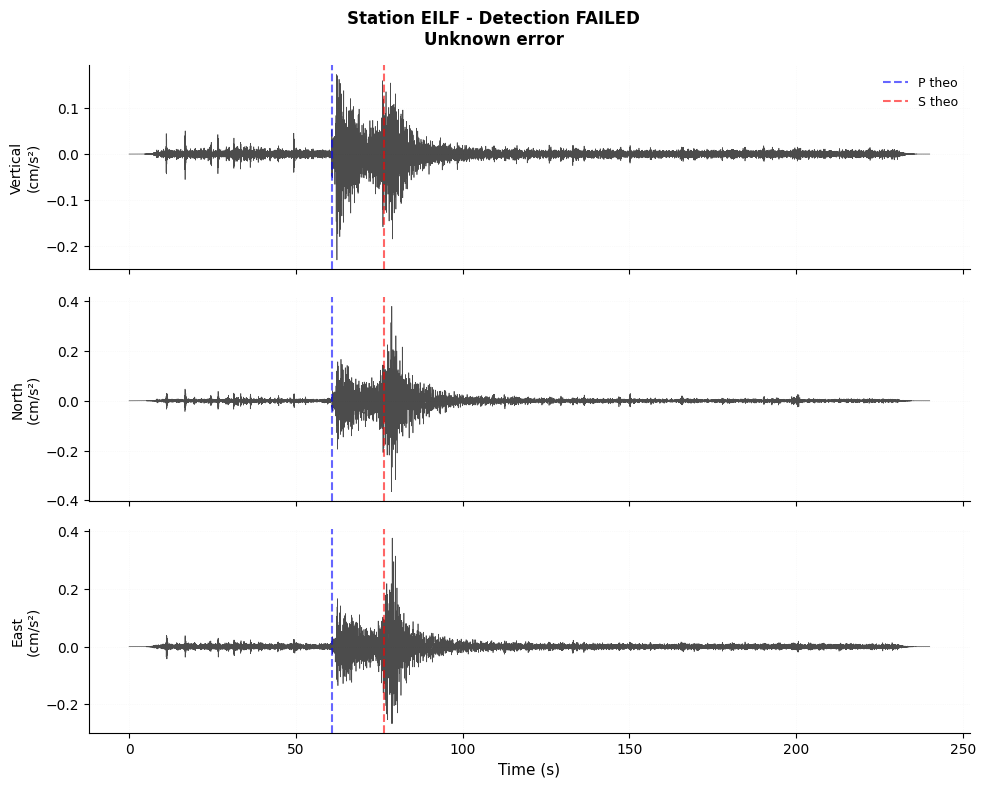

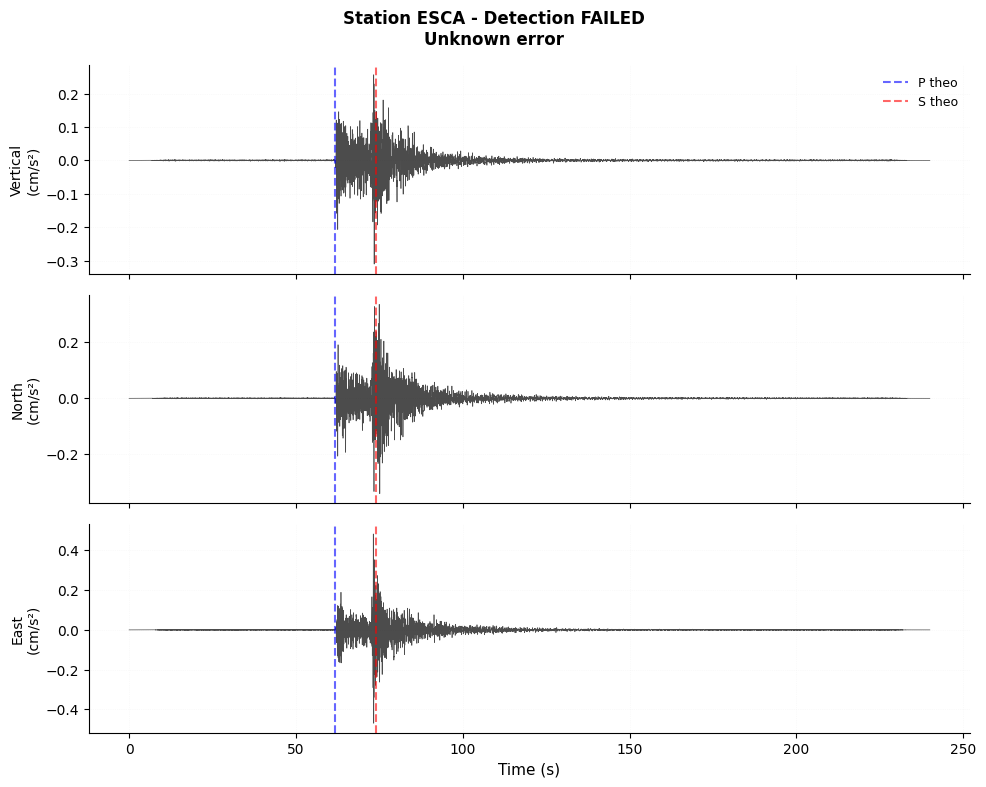

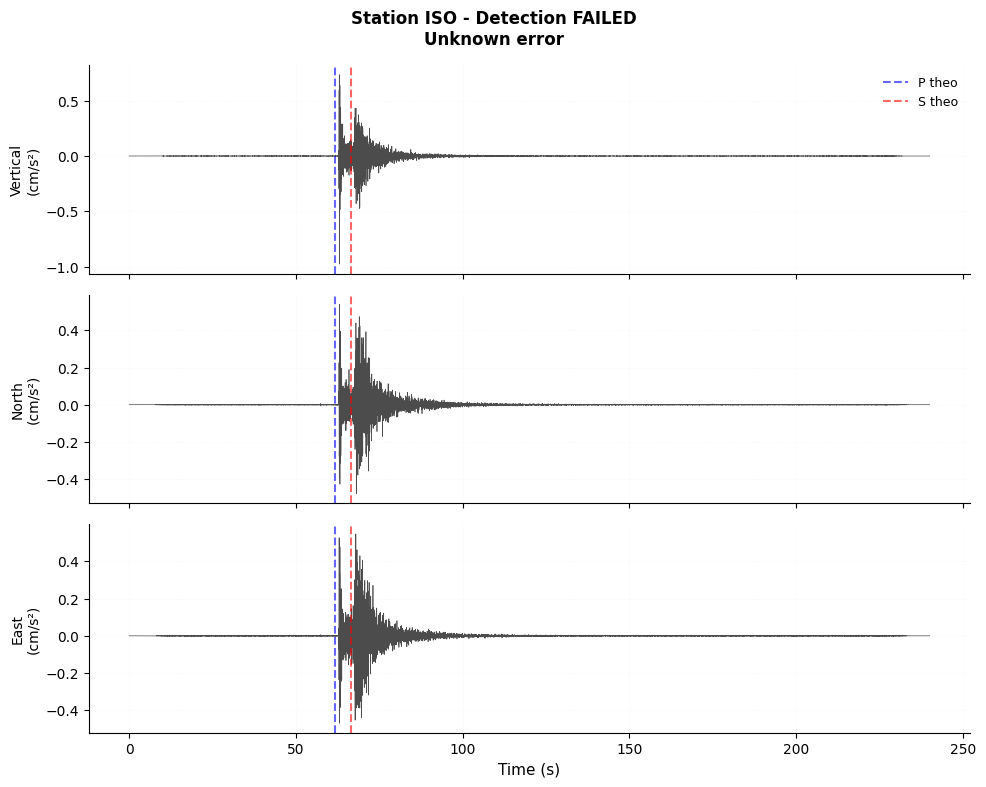

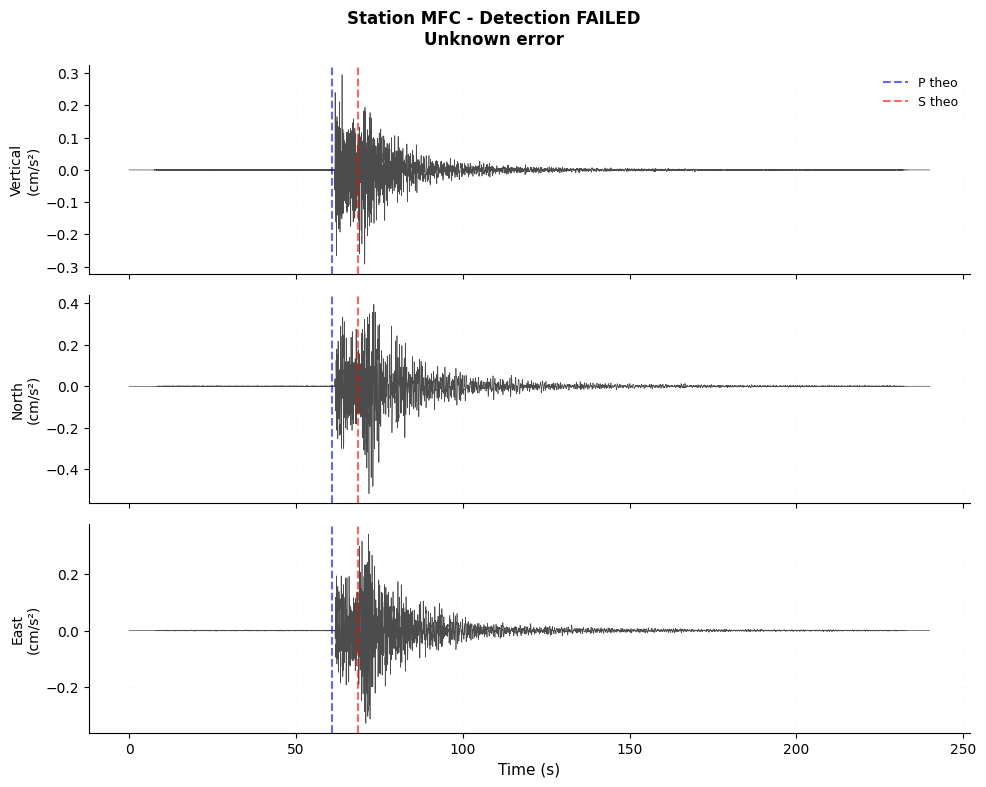

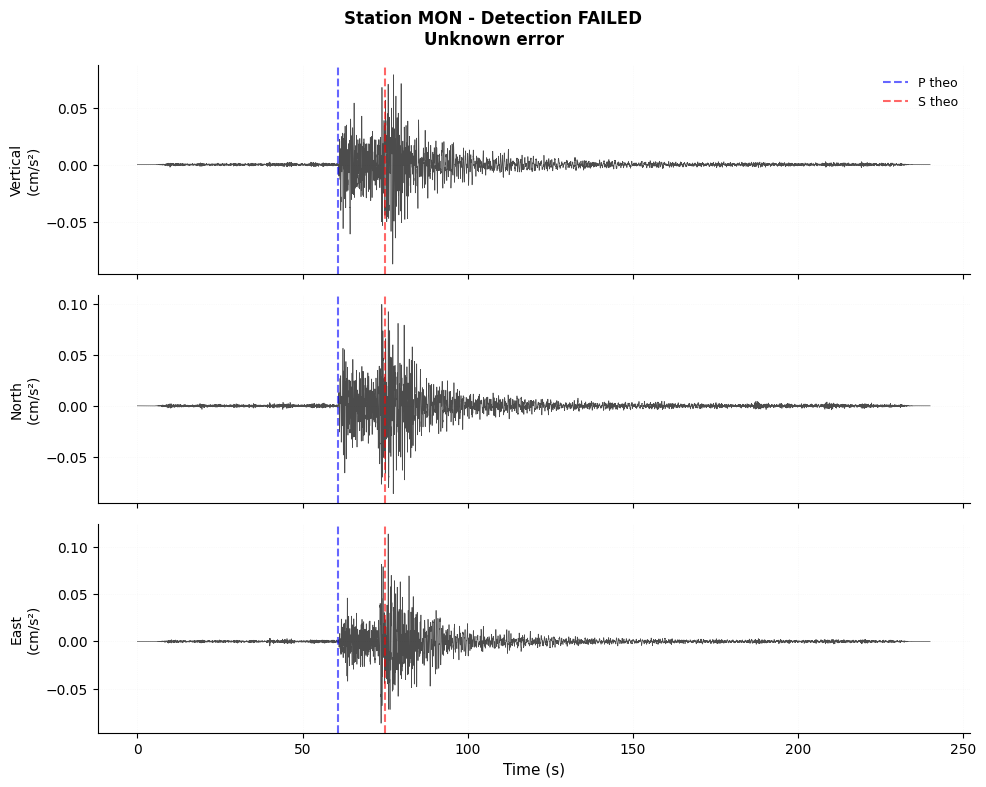

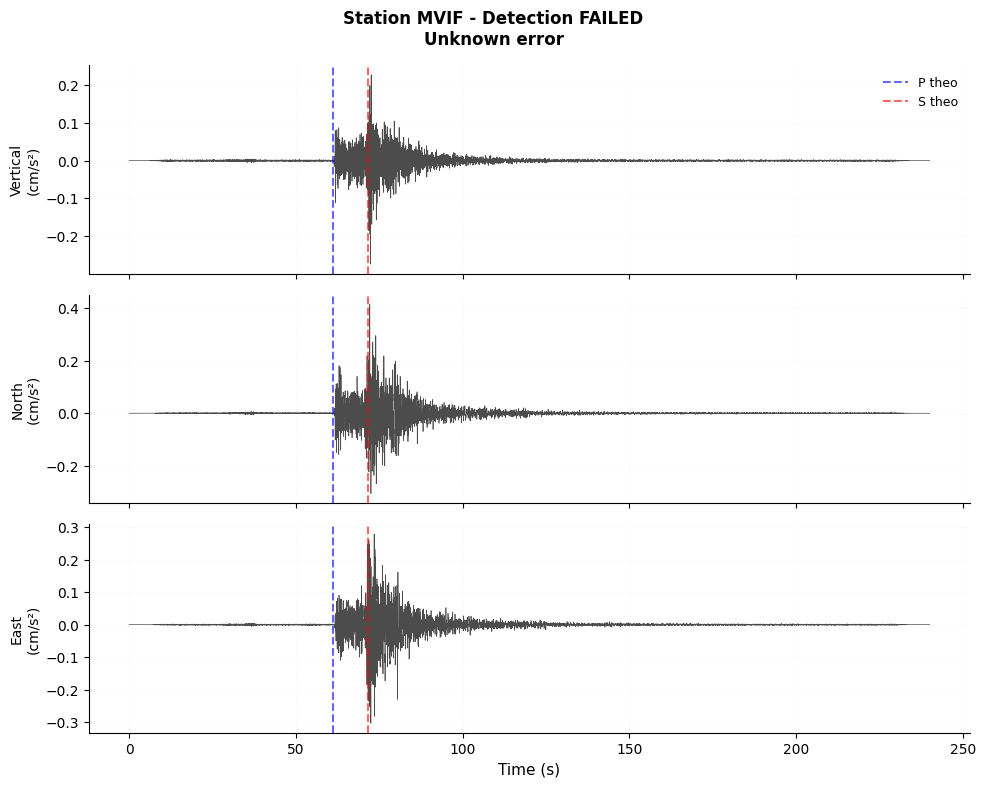

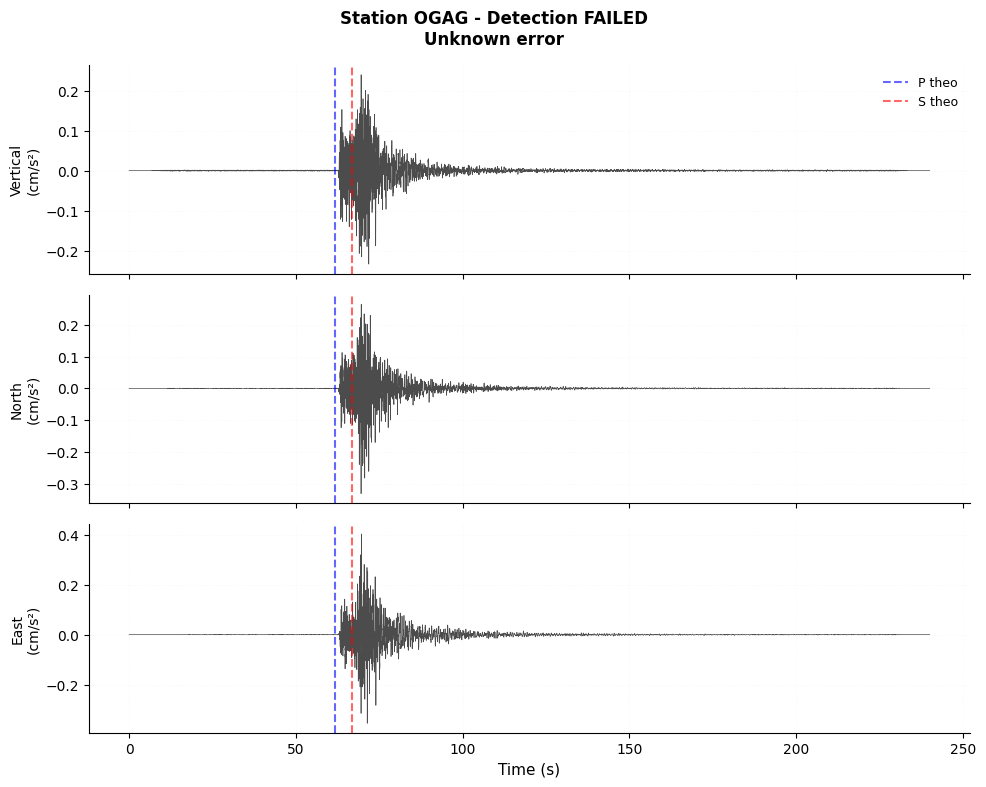

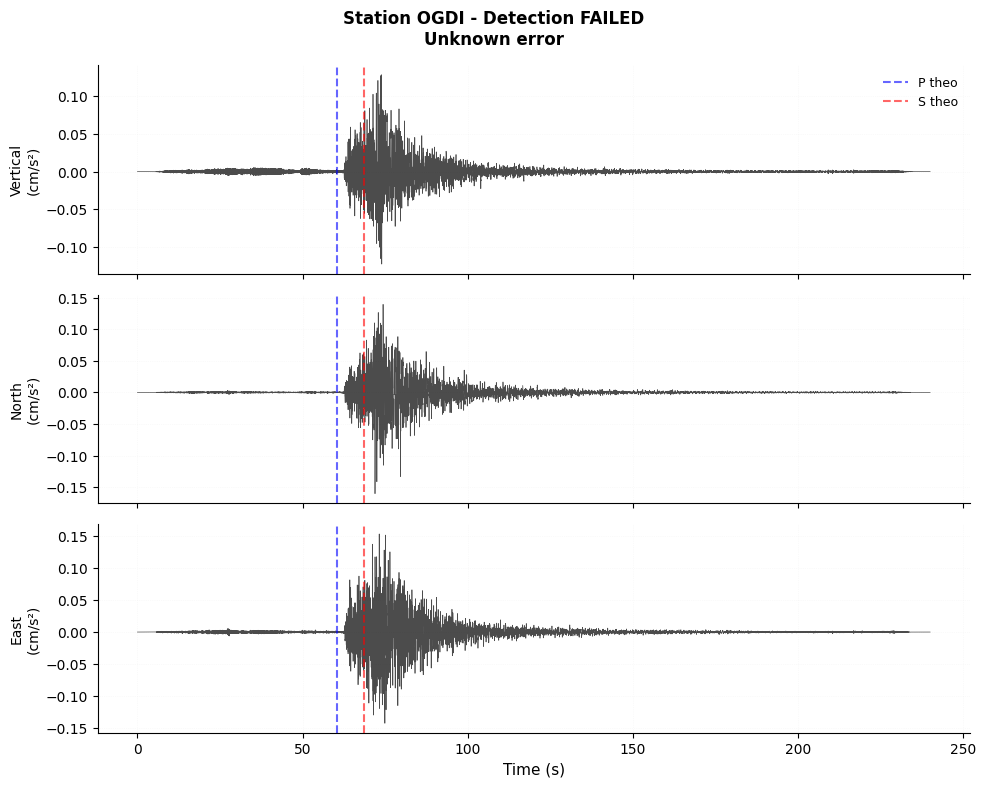

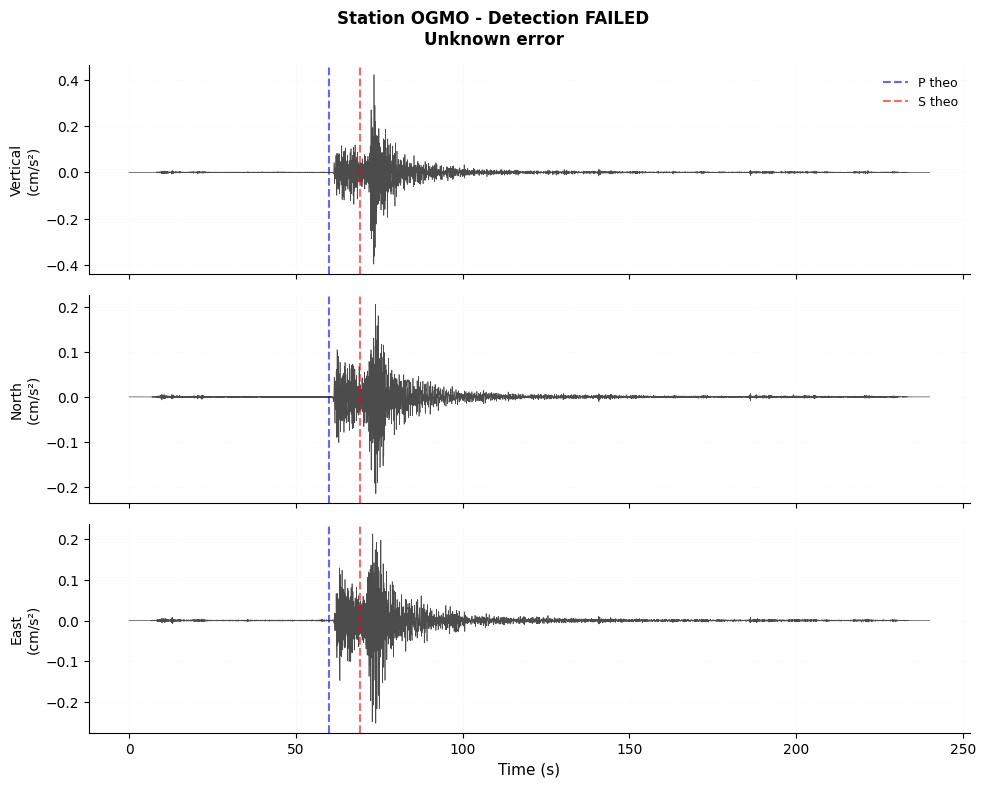

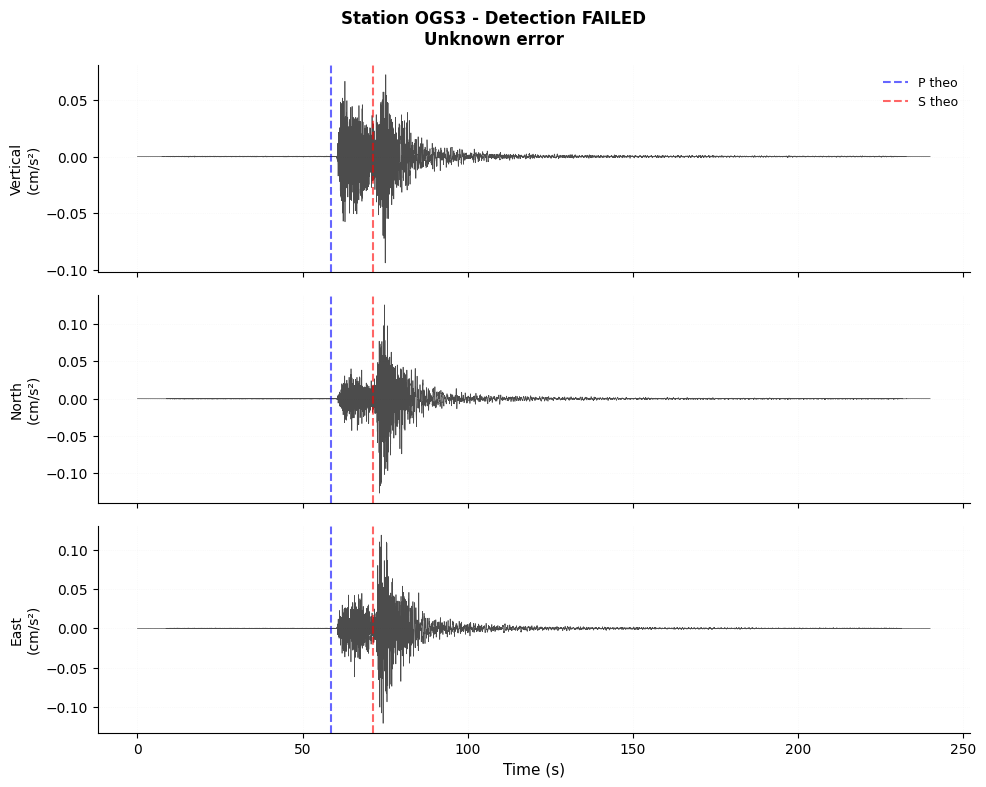

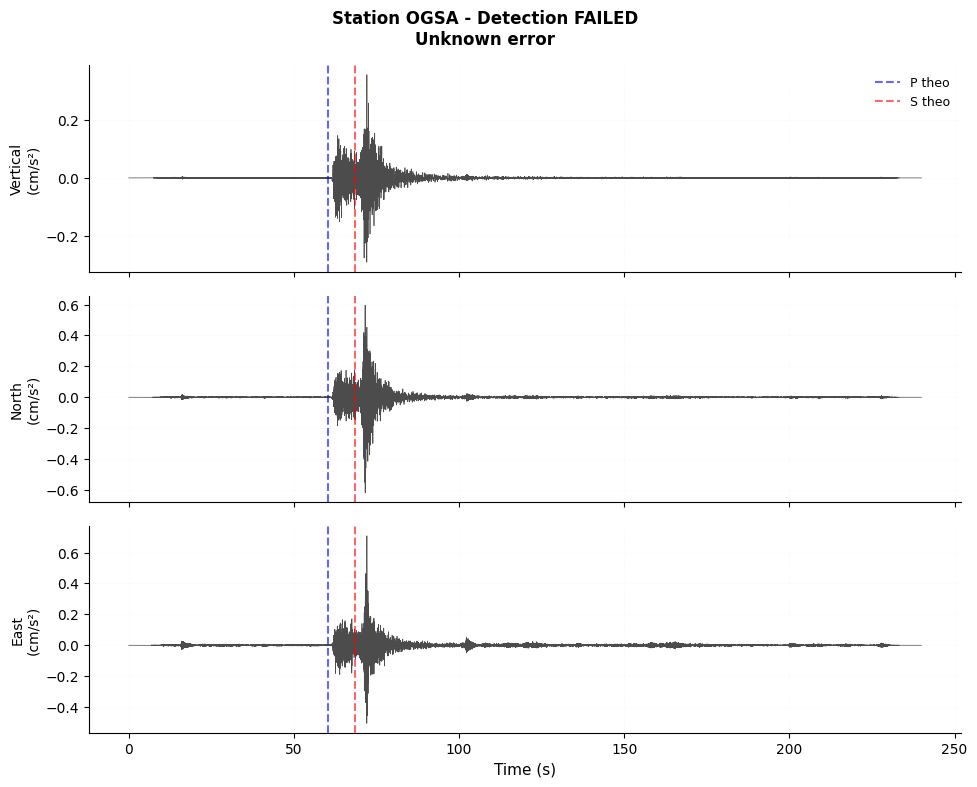

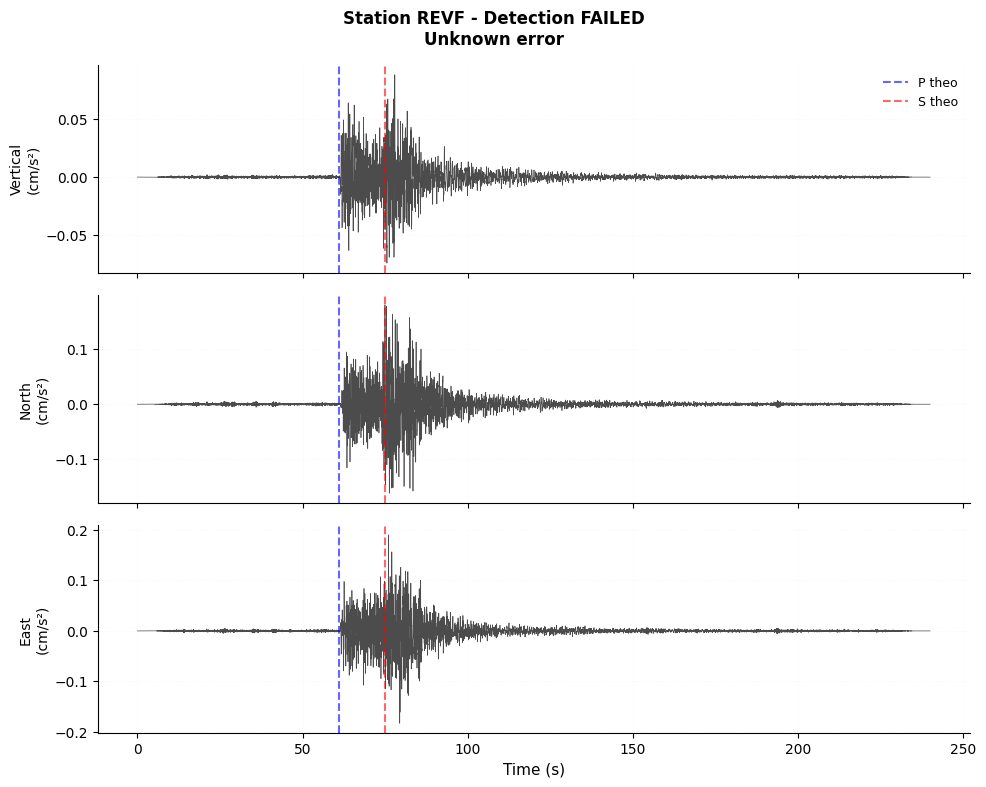

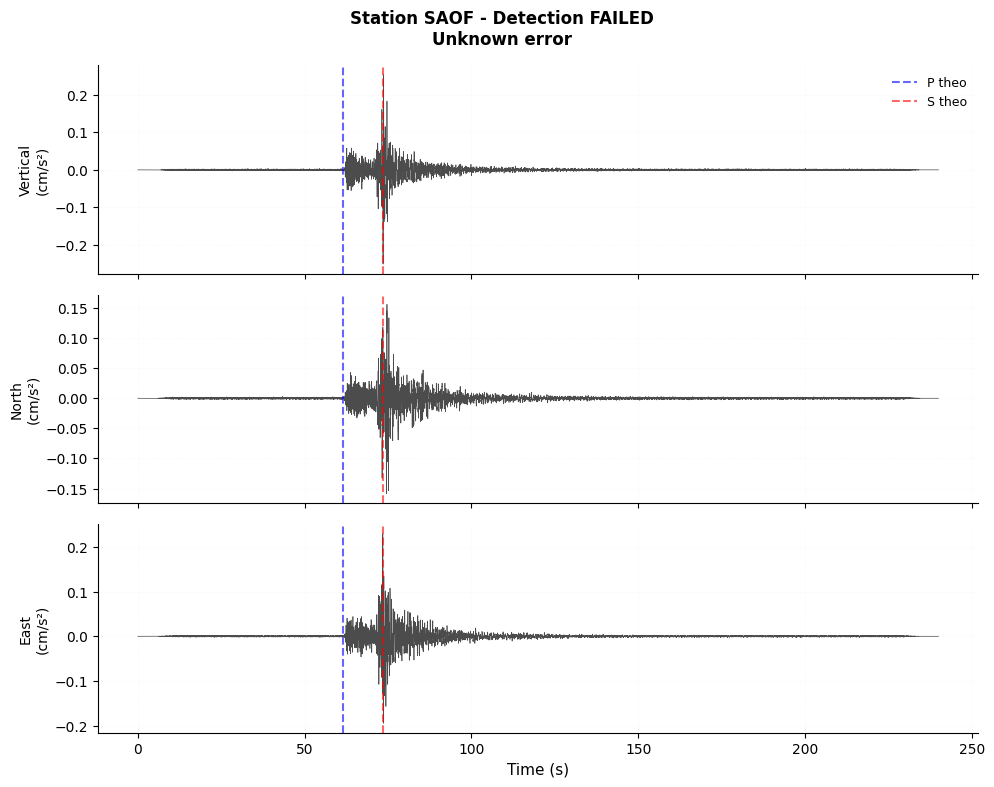

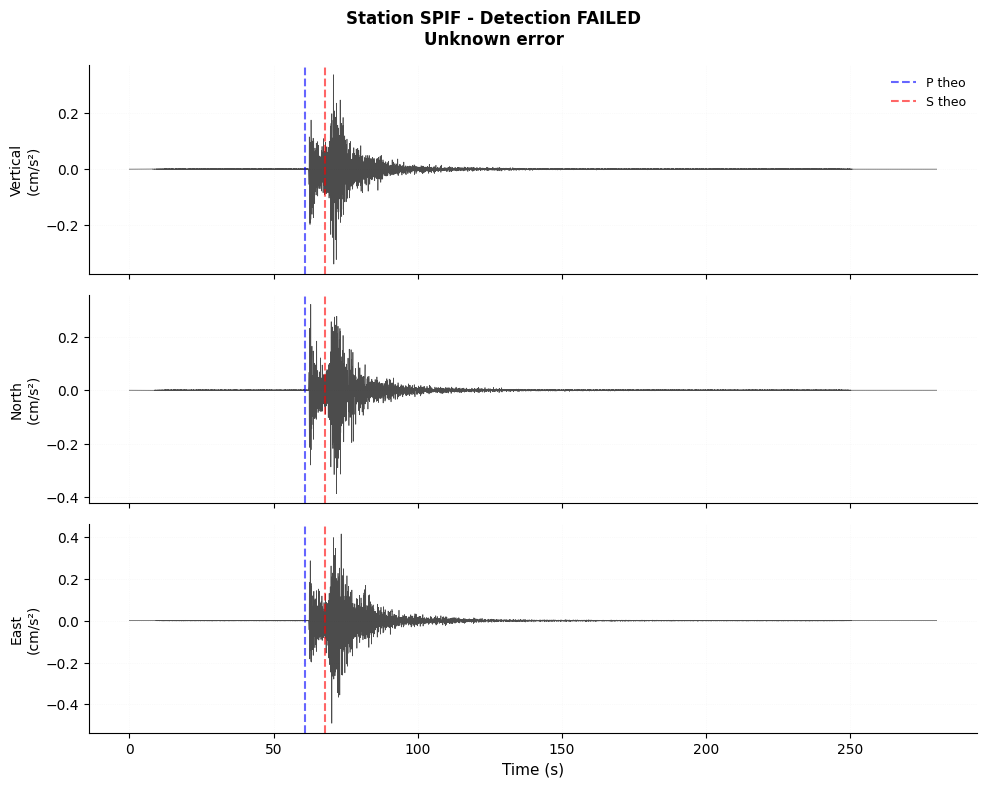

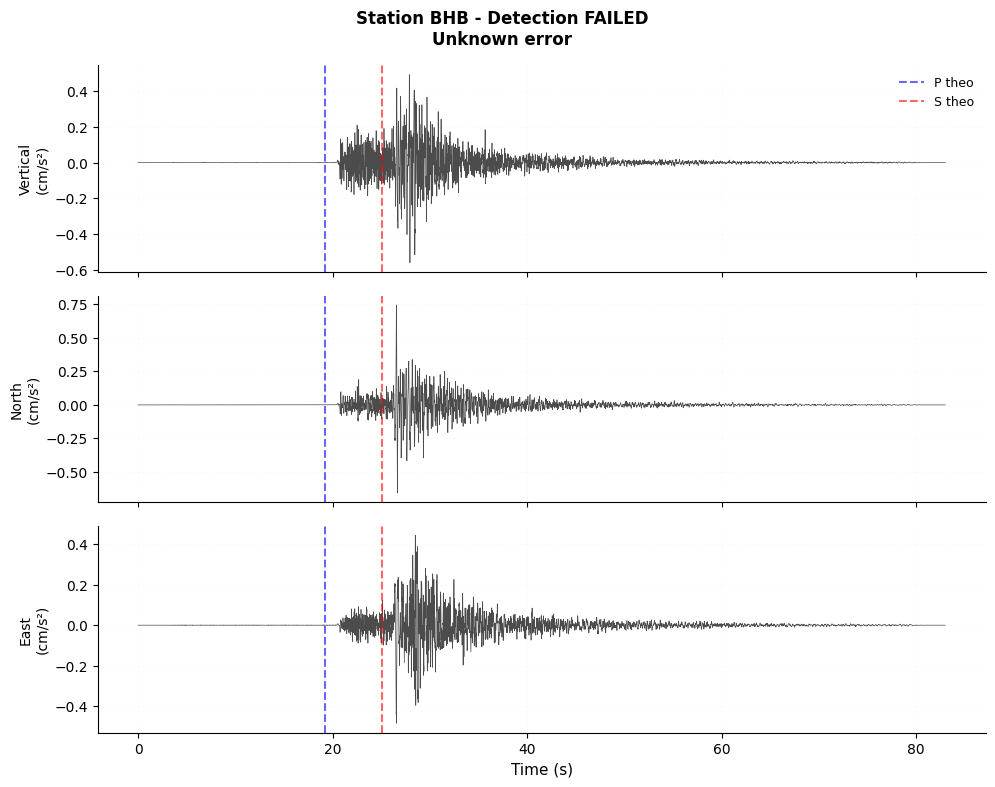

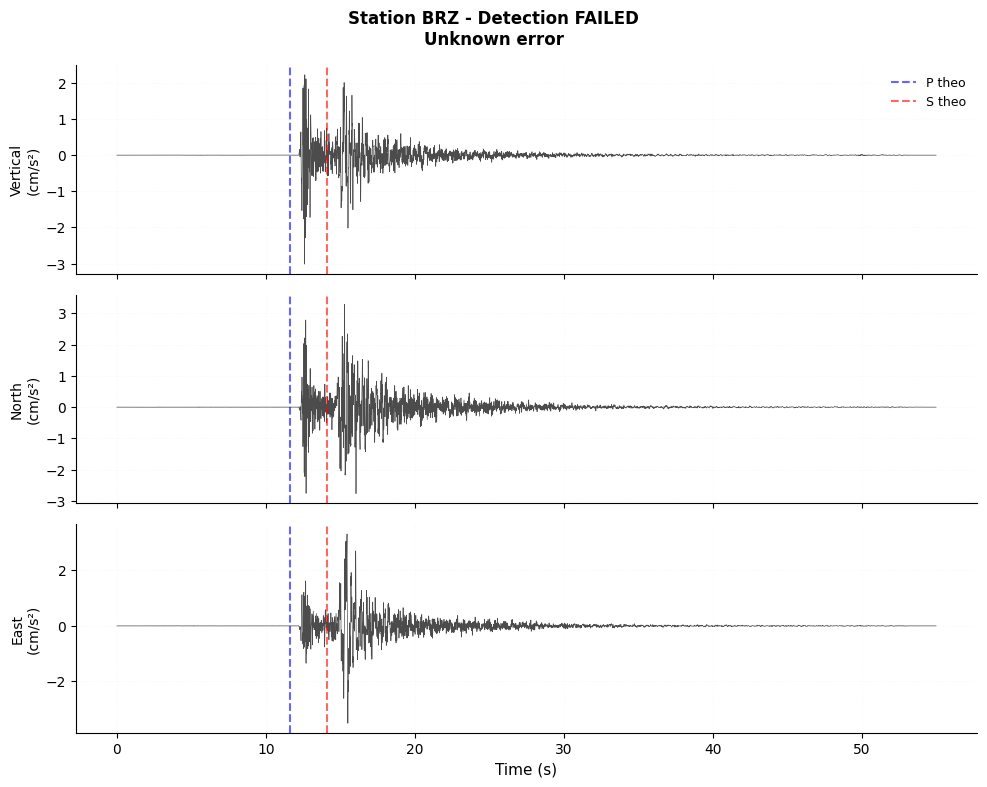

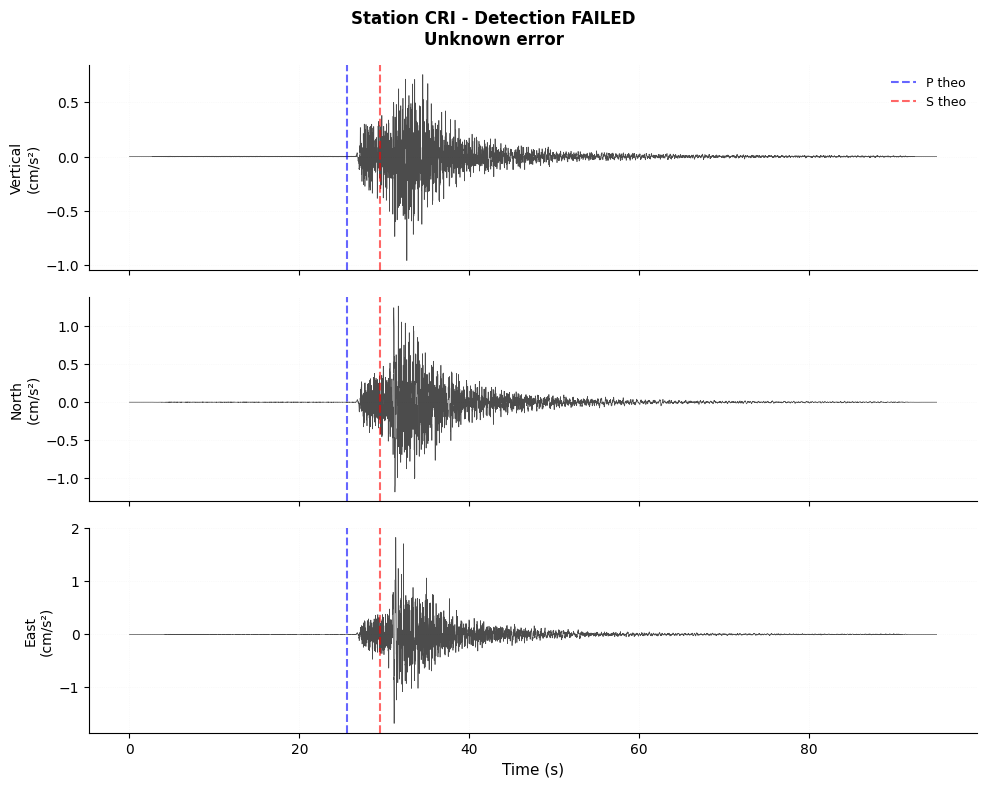

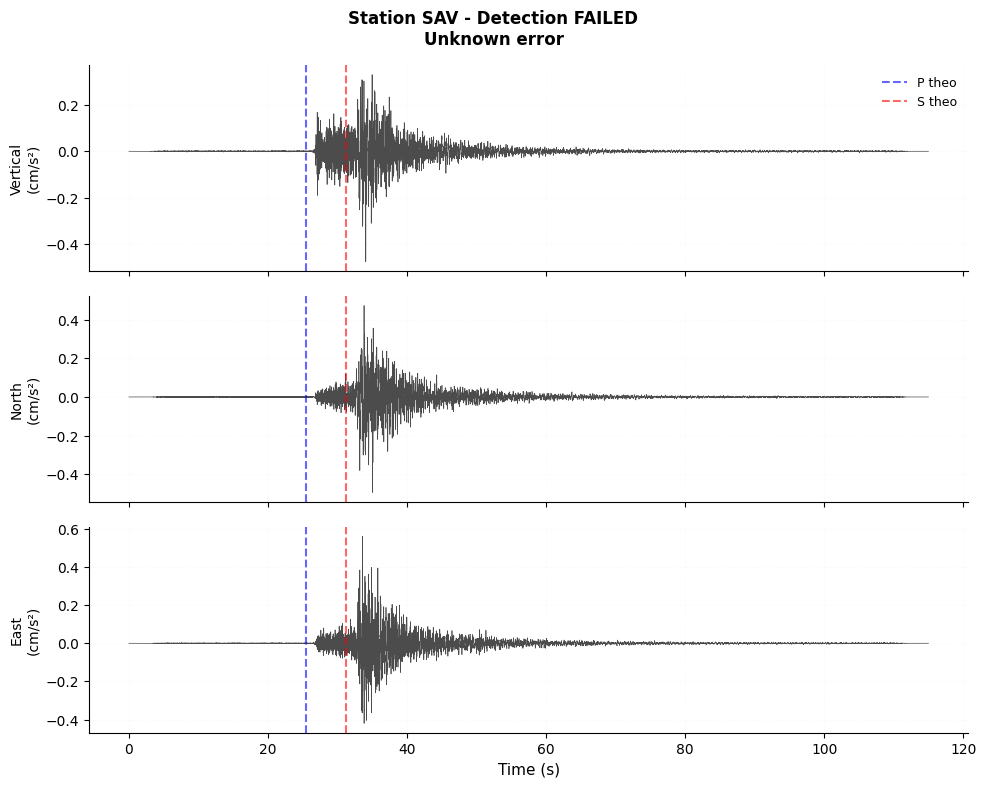

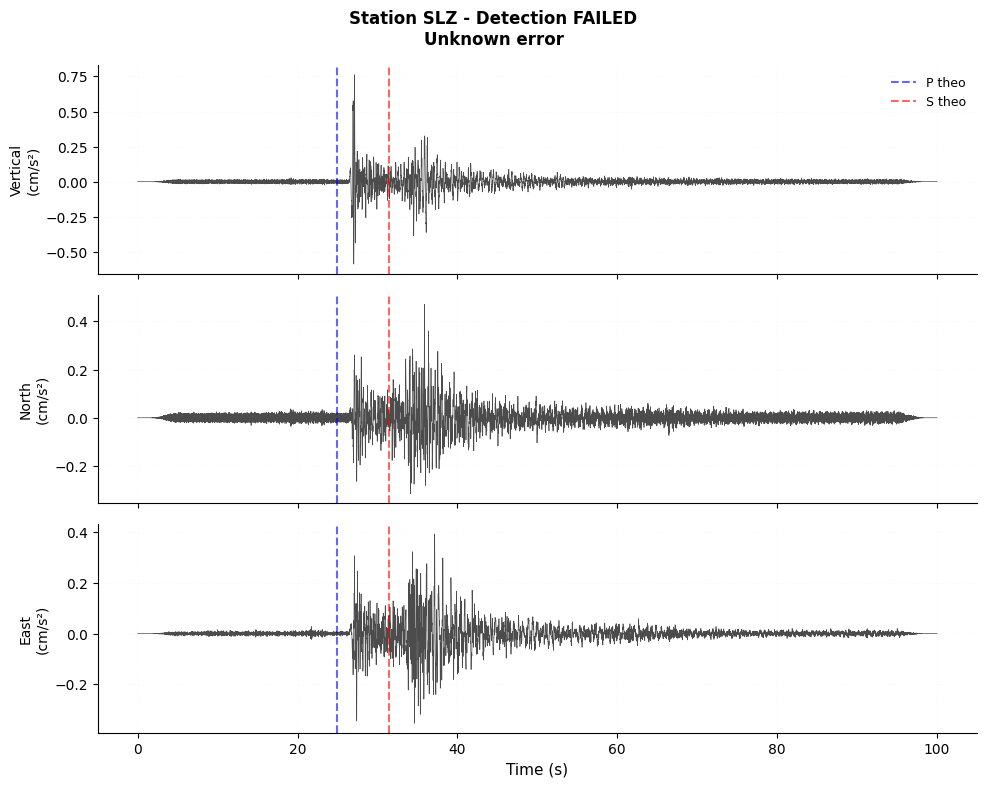

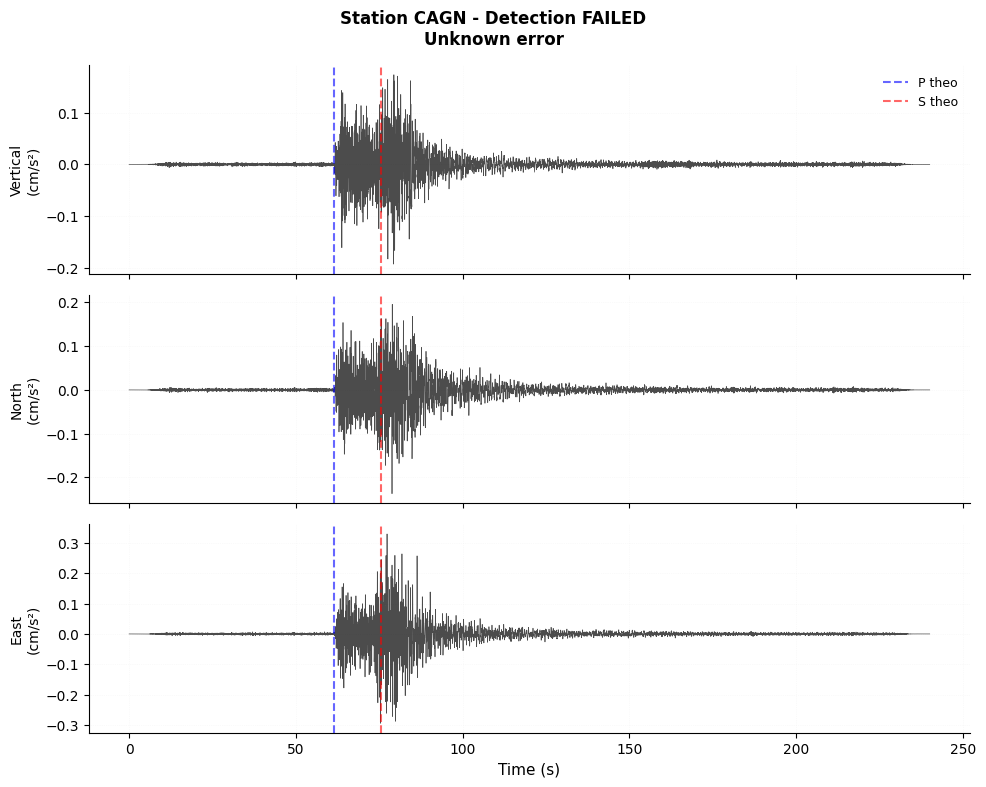

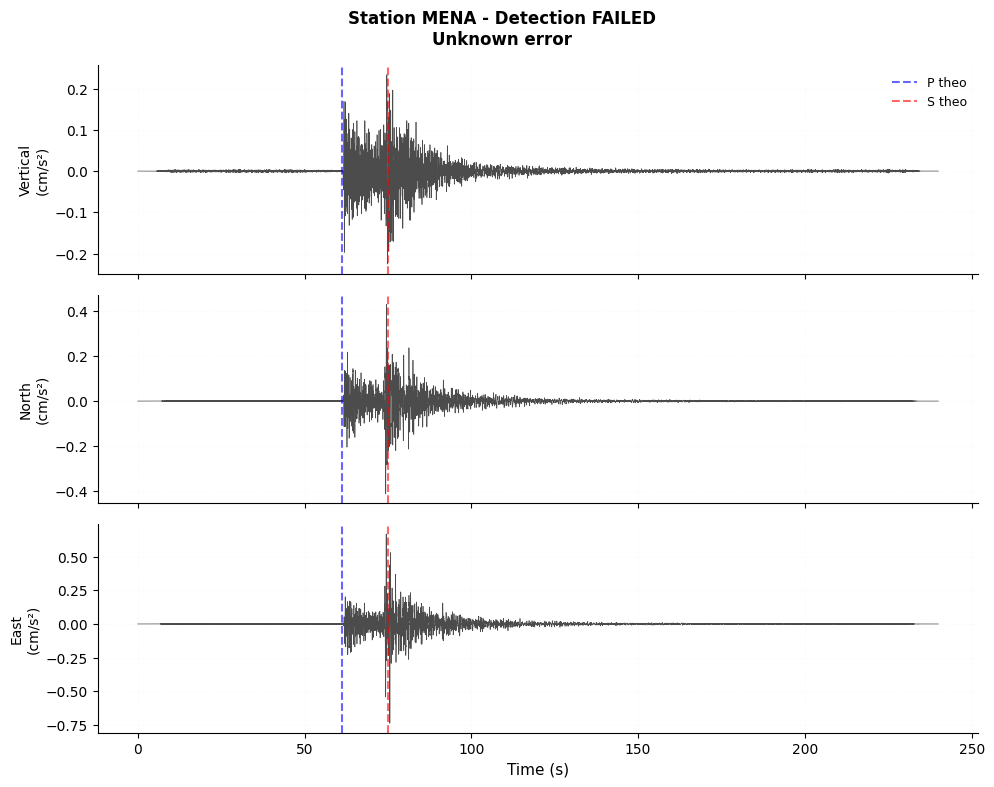

In [11]:
onset_figs= plot_onset_detection_results(signals_dict, df_meta_stations, stations=None, save_dir=FIGURES_DIR / 'onset_detection')

## Expand to component level

In [12]:
logger.info("Expanding metadata to component level...")

# Filter df_meta to only include valid stations
df_meta_valid = df_meta[df_meta['STATION_CODE'].isin(valid_stations)].copy()
logger.info(f"Filtered df_meta: {len(df_meta_valid)} components ({len(df_meta)} total)")

# Expand using filtered metadata
df_full = expand_to_component_level(df_meta_stations, df_meta_valid)

# Dynamic check based on valid_stations
expected_components = len(valid_stations) * 3
check(
    len(df_full) == expected_components, 
    f"Expanded to component level: {len(df_full)} components "
    f"(expected {expected_components} from {len(valid_stations)} stations)"
)

logger.info(f"Component-level DataFrame shape: {df_full.shape}")

INFO | Expanding metadata to component level...
INFO | Filtered df_meta: 63 components (66 total)
INFO | Expanded to component level: 63 components (expected 63 from 21 stations)
INFO | Component-level DataFrame shape: (63, 65)


Expanded onset DataFrame to component level:
  21 stations → 63 components
  (3 components per station)

Columns added:
  - t_coda_rautian, t_coda_arias, t_coda_envelope (initialized as NaN)
  - s_duration_rautian, s_duration_arias, s_duration_envelope (initialized as NaN)


## 9. Coda onset detection

In [13]:
logger.info("Calculating coda onsets for all methods...")

# Check for missing onsets
n_total = len(df_full)
n_missing_p = df_full['t_p_detected_seconds'].isna().sum()
n_missing_s = df_full['t_s_detected_seconds'].isna().sum()

if n_missing_p > 0 or n_missing_s > 0:
    logger.warning(f"Missing onsets: P={n_missing_p}, S={n_missing_s}")
    logger.warning("Filtering out components with missing onsets...")
    
    df_full_valid = df_full[
        df_full['t_p_detected_seconds'].notna() & 
        df_full['t_s_detected_seconds'].notna()
    ].copy()
    
    logger.info(f"Valid components: {len(df_full_valid)}/{n_total}")
else:
    df_full_valid = df_full.copy()

# Coda detection
df_full = add_coda_onsets_to_dataframe(
    df_full_valid, 
    signals_dict,
    threshold_arias=0.95,
    threshold_envelope=0.3,
    sampling_rate=200,
    unit='samples'
)

check('t_coda_rautian_seconds' in df_full.columns, "Coda onsets computed")
logger.info("Coda onsets computed for all methods: rautian, arias, envelope, median")

# Summary
print("\nCoda onset summary (mean S-wave duration):")
for method in ['rautian', 'arias', 'envelope', 'median']:
    col = f's_duration_{method}_seconds'
    if col in df_full.columns:
        mean_dur = df_full[col].mean()
        std_dur = df_full[col].std()
        print(f"  {method.capitalize():10s}: {mean_dur:.2f} ± {std_dur:.2f}s")

INFO | Calculating coda onsets for all methods...


Pre-computing Rautian coda onset per station (dual representation)...
  Computed Rautian for 21 stations
Calculating Arias, Envelope, and Median coda onsets for 63 components...


INFO | Coda onsets computed
INFO | Coda onsets computed for all methods: rautian, arias, envelope, median



Done!
  Successfully processed: 63/63 components
  Failed: 0/63 components
  Created columns with dual representation (_samples + _seconds)
  Legacy columns (no suffix) point to: samples

Coda onset summary (mean S-wave duration):
  Rautian   : 16.75 ± 7.57s
  Arias     : 20.08 ± 5.80s
  Envelope  : 17.32 ± 7.08s
  Median    : 18.63 ± 5.69s


## 10. Windowing

In [14]:
for method in ['rautian', 'arias', 'envelope', 'median']:
    logger.info(f"Segmenting signals with {method} coda method...")
    
    # Windowing
    windowed_signals = segment_all_signals(
        signals_dict, 
        df_full, 
        coda_method=method
    )
    
    # Save
    output_file = SIGNALS_PROCESSED_EXPORT / f'windowed_{DATA_TYPE}_{method}_phasenet.pkl'
    with open(output_file, 'wb') as f:
        pickle.dump(windowed_signals, f)
    
    logger.info(f"Saved: {output_file}")
    logger.info(f"File size: {output_file.stat().st_size / 1e6:.2f} MB")

    all_stations = list(windowed_signals.keys())
    plot_multiple_stations(
    stations=all_stations,
    signals_dict=signals_dict,
    windowed_signals=windowed_signals,
    df_onsets=df_full,
    coda_method=method,
    save_dir= FIGURES_DIR / f'windows_{method}',
    close_after_save=True 
)

INFO | Segmenting signals with rautian coda method...
INFO | Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/03_phase_identification_phasenet/acceleration/windowed_acceleration_rautian_phasenet.pkl
INFO | File size: 33.07 MB


Note: Converted pre_p_duration to 1000 samples @ 200Hz

SIGNAL SEGMENTATION SUMMARY
Successfully segmented: 63 signals from 21 stations
Skipped (no onset data): 0
Skipped (missing values): 0
Skipped (errors): 0

Coda detection method: rautian
Working unit: samples
Sampling rate: 200 Hz
Pre-event strategy: 1000

Pre-event window durations:
  Target: 1000 samples (5.00s)
  Actual mean: 5.00s (1000 samp)
  Actual range: [5.00, 5.00]s

Plotting 21 stations...
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_rautian/EILF_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_rautian/ESCA_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_rautian/ISO_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-se

INFO | Segmenting signals with arias coda method...
INFO | Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/03_phase_identification_phasenet/acceleration/windowed_acceleration_arias_phasenet.pkl
INFO | File size: 33.07 MB


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_rautian/MENA_windows.pdf
  Progress: 21/21 stations
Done! Plotted 21 stations
Note: Converted pre_p_duration to 1000 samples @ 200Hz

SIGNAL SEGMENTATION SUMMARY
Successfully segmented: 63 signals from 21 stations
Skipped (no onset data): 0
Skipped (missing values): 0
Skipped (errors): 0

Coda detection method: arias
Working unit: samples
Sampling rate: 200 Hz
Pre-event strategy: 1000

Pre-event window durations:
  Target: 1000 samples (5.00s)
  Actual mean: 5.00s (1000 samp)
  Actual range: [5.00, 5.00]s

Plotting 21 stations...
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_arias/EILF_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_arias/ESCA_windows.pdf
Saved: /Us

INFO | Segmenting signals with envelope coda method...


...


Plotting 21 stations...
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_envelope/EILF_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_envelope/ESCA_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_envelope/ISO_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_envelope/MFC_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_envelope/MON_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_envelope/MVIF_windows.pdf
Saved:

INFO | Segmenting signals with median coda method...


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_envelope/CAGN_windows.pdf
  Progress: 20/21 stations
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_envelope/MENA_windows.pdf
  Progress: 21/21 stations
Done! Plotted 21 stations
Note: Converted pre_p_duration to 1000 samples @ 200Hz

SIGNAL SEGMENTATION SUMMARY
Successfully segmented: 63 signals from 21 stations
Skipped (no onset data): 0
Skipped (missing values): 0
Skipped (errors): 0

Coda detection method: median
Working unit: samples
Sampling rate: 200 Hz
Pre-event strategy: 1000

Pre-event window durations:
  Target: 1000 samples (5.00s)
  Actual mean: 5.00s (1000 samp)
  Actual range: [5.00, 5.00]s


INFO | Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/03_phase_identification_phasenet/acceleration/windowed_acceleration_median_phasenet.pkl
INFO | File size: 33.07 MB



Plotting 21 stations...
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_median/EILF_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_median/ESCA_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_median/ISO_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_median/MFC_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_median/MON_windows.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03b_phase_identification_phasenet/acceleration/windows_median/MVIF_windows.pdf
Saved: /Users/giul

## Quality control

In [15]:
logger.info("Running quality control on windowed signals...")
logger.info("=" * 80)

# Run QC per ogni metodo di coda
qc_results = {}

for method in ['rautian', 'arias', 'envelope', 'median']:
    logger.info(f"\n{method.upper()} METHOD")
    logger.info("-" * 40)
    
    # Load windowed signals
    input_file = SIGNALS_PROCESSED_EXPORT / f'windowed_{DATA_TYPE}_{method}_phasenet.pkl'
    
    if not input_file.exists():
        logger.warning(f"File not found: {input_file}")
        continue
    
    with open(input_file, 'rb') as f:
        windowed_signals = pickle.load(f)
    
    # Run QC
    qc_result = quality_control_all_stations(
        windowed_signals,
        df_full,
        df_meta_stations,
        peak_column=PEAK_COLUMN,
        time_peak_column=TIME_PEAK_COLUMN,
        snr_threshold=3.0,
        coda_method=method
    )
    
    qc_results[method] = qc_result
    
    # Print summary
    print_quality_control_summary(qc_result)

logger.info("\n" + "=" * 80)
logger.info("Quality control complete for all methods")

INFO | Running quality control on windowed signals...
INFO | ================================================================================
INFO | 
RAUTIAN METHOD
INFO | ----------------------------------------
INFO | 
ARIAS METHOD
INFO | ----------------------------------------
INFO | 
ENVELOPE METHOD
INFO | ----------------------------------------
INFO | 
MEDIAN METHOD
INFO | ----------------------------------------
INFO | 
INFO | Quality control complete for all methods



Quality Control Summary

BHB
  ├─ HNE: [✓ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]
  ├─ HNN: [✓ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]
  └─ HNZ: [✓ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]

BRZ
  ├─ HGE: [✗ Peak] [✓ MonoP] [✓ MonoS] [✗ SNRP] [✗ SNRS]
  ├─ HGN: [✗ Peak] [✓ MonoP] [✓ MonoS] [✗ SNRP] [✗ SNRS]
  └─ HGZ: [✗ Peak] [✓ MonoP] [✓ MonoS] [✗ SNRP] [✗ SNRS]

CAGN
  ├─ HNE: [✓ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]
  ├─ HNN: [✓ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]
  └─ HNZ: [✓ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]

CRI
  ├─ HNE: [✓ Peak] [✓ MonoP] [✓ MonoS] [✗ SNRP] [✓ SNRS]
  ├─ HNN: [✓ Peak] [✓ MonoP] [✓ MonoS] [✗ SNRP] [✓ SNRS]
  └─ HNZ: [✗ Peak] [✓ MonoP] [✓ MonoS] [✗ SNRP] [✓ SNRS]

EILF
  ├─ HNE: [✓ Peak] [✓ MonoP] [✓ MonoS] [✗ SNRP] [✓ SNRS]
  ├─ HNN: [✓ Peak] [✓ MonoP] [✓ MonoS] [✗ SNRP] [✓ SNRS]
  └─ HNZ: [✗ Peak] [✓ MonoP] [✓ MonoS] [✗ SNRP] [✓ SNRS]

ESCA
  ├─ HNE: [✓ Peak] [✗ MonoP] [✓ MonoS] [✗ SNRP] [✓ SNRS]
  ├─ HNN: [✓ Peak] [✗ MonoP] [